In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

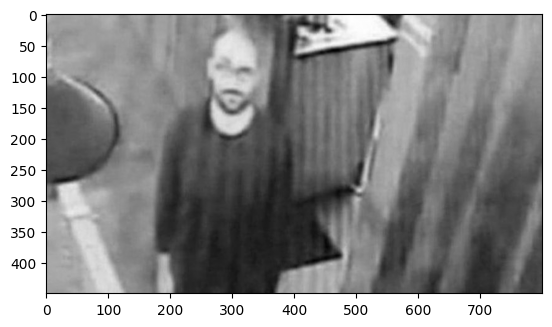

In [2]:
c1 = cv.imread('backup.jpg')
backup = cv.cvtColor(c1, cv.COLOR_BGR2GRAY)
plt.imshow(backup, cmap='gray')
plt.axis('on')
plt.show()

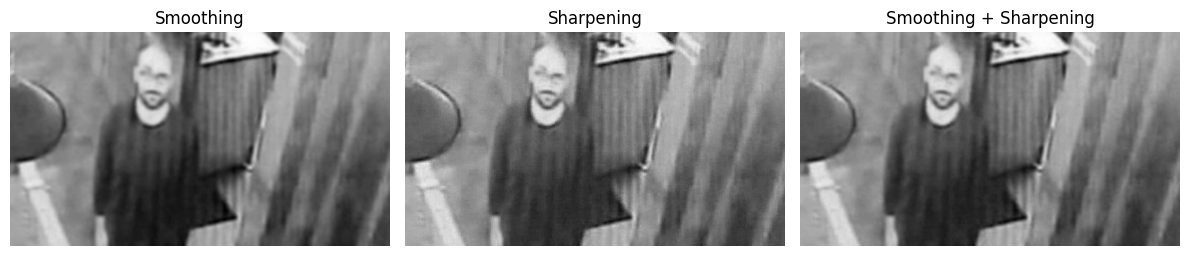

In [ ]:
img = cv2.imread('backup.jpg', 0)

smoothing = cv2.GaussianBlur(img, (7, 7), 0)

kernel_sharp = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

sharpening = cv2.filter2D(img, -1, kernel_sharp)

smooth_sharp = cv2.filter2D(smoothing, -1, kernel_sharp)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(smoothing, cmap='gray')
plt.title('Smoothing')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sharpening, cmap='gray')
plt.title('Sharpening')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(smooth_sharp, cmap='gray')
plt.title('Smoothing + Sharpening')
plt.axis('off')

plt.tight_layout()
plt.show()

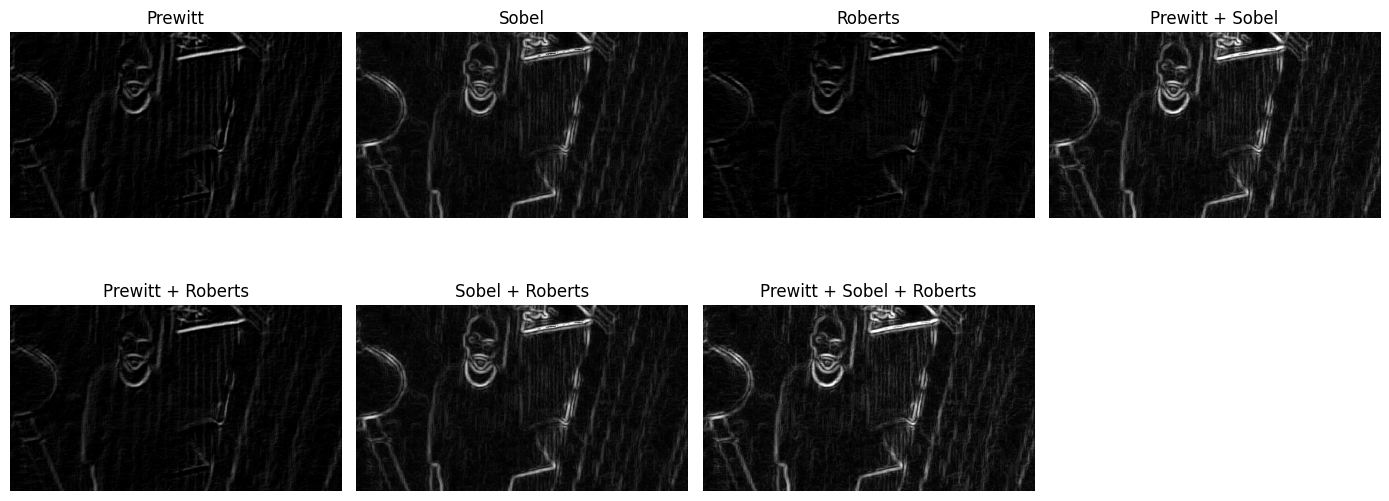

In [ ]:
image = cv2.imread('backup.jpg')

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

kernelx_prewitt = np.array([[1, 0, -1],
                            [1, 0, -1],
                            [1, 0, -1]])

kernely_prewitt = np.array([[1, 1, 1],
                            [0, 0, 0],
                            [-1, -1, -1]])

prewitt_x = cv2.filter2D(gray, -1, kernelx_prewitt)
prewitt_y = cv2.filter2D(gray, -1, kernely_prewitt)
prewitt = cv2.addWeighted(prewitt_x, 0.5, prewitt_y, 0.5, 0)

sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

sobel = cv2.magnitude(sobel_x, sobel_y)
sobel = np.uint8(sobel)

kernelx_roberts = np.array([[1, 0],
                            [0, -1]])

kernely_roberts = np.array([[0, 1],
                            [-1, 0]])

roberts_x = cv2.filter2D(gray, -1, kernelx_roberts)
roberts_y = cv2.filter2D(gray, -1, kernely_roberts)

roberts = cv2.addWeighted(roberts_x, 0.5, roberts_y, 0.5, 0)

prewitt_sobel = cv2.add(prewitt, sobel)
prewitt_roberts = cv2.add(prewitt, roberts)
sobel_roberts = cv2.add(sobel, roberts)

all_combined = cv2.add(prewitt, sobel)
all_combined = cv2.add(all_combined, roberts)

titles = [
    'Prewitt', 'Sobel', 'Roberts', 'Prewitt + Sobel',
    'Prewitt + Roberts', 'Sobel + Roberts',
    'Prewitt + Sobel + Roberts'
]

images = [
    prewitt, sobel, roberts, prewitt_sobel,
    prewitt_roberts, sobel_roberts,
    all_combined
]

plt.figure(figsize=(14, 6))

for i in range(len(images)):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

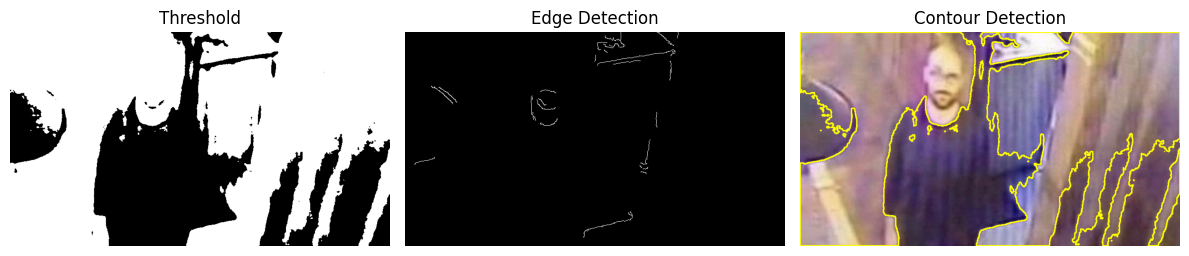

In [10]:
image = cv2.imread('backup.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

_, threshold = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY)

edges = cv2.Canny(gray, 100, 200)

contours, _ = cv2.findContours(
    threshold,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

result = image_rgb.copy()

cv2.drawContours(result, contours, -1, (255, 255, 0), 2)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(threshold, cmap='gray')
plt.title('Threshold')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(edges, cmap='gray')
plt.title('Edge Detection')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(result)
plt.title('Contour Detection')
plt.axis('off')

plt.tight_layout()
plt.show()

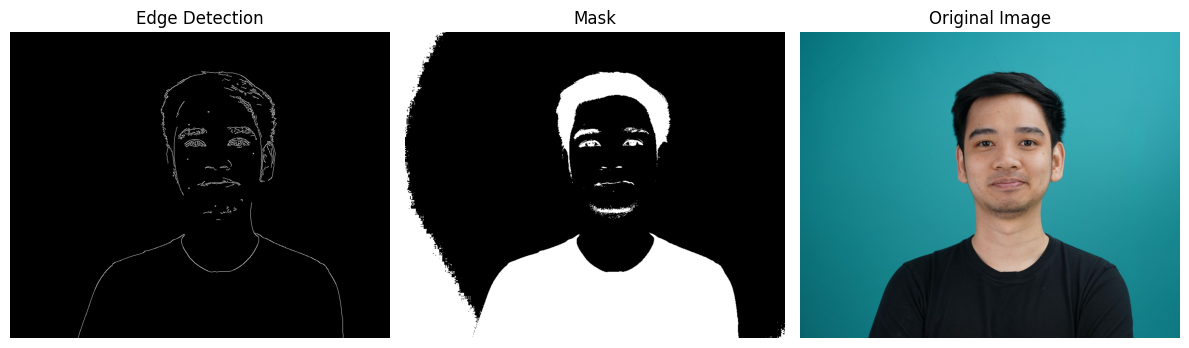

In [44]:
image = cv2.imread('david.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray, 100, 200)

_, mask = cv2.threshold(gray, 90, 255, cv2.THRESH_BINARY_INV)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(edges, cmap='gray')
plt.title('Edge Detection')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title('Mask')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')

plt.tight_layout()
plt.show()

In [22]:
def spesifikasi_histogram(citra_asal, citra_target):
    hist_asal = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)

    for i in range(citra_asal.shape[0]):
        for j in range(citra_asal.shape[1]):
            nilai_pixel = citra_asal[i, j]
            hist_asal[nilai_pixel] += 1

    for i in range(citra_target.shape[0]):
        for j in range(citra_target.shape[1]):
            nilai_pixel = citra_target[i, j]
            hist_target[nilai_pixel] += 1

    cdf_asal = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)

    cdf_asal[0] = hist_asal[0]
    cdf_target[0] = hist_target[0]

    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i-1] + hist_asal[i]
        cdf_target[i] = cdf_target[i-1] + hist_target[i]

    cdf_asal = cdf_asal / cdf_asal[-1]
    cdf_target = cdf_target / cdf_target[-1]

    map_hist = np.zeros(256, dtype=np.uint8)

    for i in range(256):                   
        min_diff = float('inf')
        mapping_value = 0
        
        for j in range(256):               
            diff = abs(cdf_asal[i] - cdf_target[j])
            if diff < min_diff:
                min_diff = diff
                mapping_value = j
                
        map_hist[i] = mapping_value

    height, width = citra_asal.shape
    hasil = np.zeros((height, width), dtype=np.uint8)

    for i in range(height):
        for j in range(width):
            nilai_pixel = citra_asal[i, j]
            hasil[i, j] = map_hist[nilai_pixel]

    return hasil

In [24]:
backup = spesifikasi_histogram(windut_gray)

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(windah, cmap='gray')
plt.title("Hasil Spesifikasi")
plt.axis('on')

NameError: name 'windut_gray' is not defined

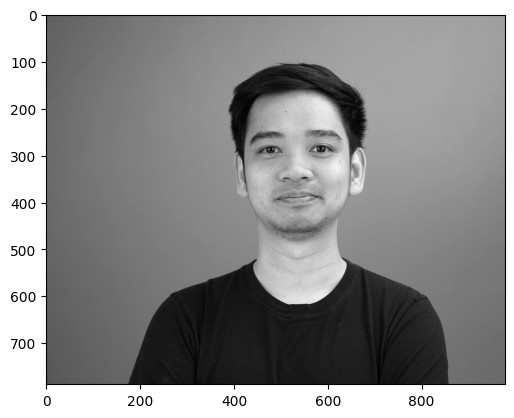

In [36]:
c1 = cv.imread('david.jpg')
backup = cv.cvtColor(c1, cv.COLOR_BGR2GRAY)
plt.imshow(david, cmap='gray')
plt.axis('on')
plt.show()